<a href="https://colab.research.google.com/github/taimaa44/Tempo_testing-/blob/main/weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
df=pd.read_csv("weatherHistory.csv")

In [ ]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.47,7.39,0.89,14.12,251.00,15.83,0.00,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.36,7.23,0.86,14.26,259.00,15.83,0.00,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.38,9.38,0.89,3.93,204.00,14.96,0.00,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.29,5.94,0.83,14.10,269.00,15.83,0.00,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.76,6.98,0.83,11.04,259.00,15.83,0.00,1016.51,Partly cloudy throughout the day.


In [ ]:
df.shape

(96453, 12)

In [ ]:

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], errors='coerce', utc=True)


In [ ]:
df['Formatted Date'].dtype


datetime64[ns, UTC]

In [ ]:

df['Date'] = df['Formatted Date'].dt.date
df['Time'] = df['Formatted Date'].dt.time


In [ ]:
df['Date_ordinal'] = pd.to_datetime(df['Date']).map(pd.Timestamp.toordinal)


In [ ]:
df['Time_seconds'] = df['Time'].apply(lambda t: t.hour*3600 + t.minute*60 + t.second)


In [ ]:
df.shape

(96453, 16)

In [ ]:
df.dtypes

,0
Formatted Date,"datetime64[ns, UTC]"
Summary,object
Precip Type,object
Temperature (C),float64
Apparent Temperature (C),float64
Humidity,float64
Wind Speed (km/h),float64
Wind Bearing (degrees),float64
Visibility (km),float64
Loud Cover,float64


In [ ]:
df = df.drop(columns=['Formatted Date','Loud Cover'])


In [ ]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Date_ordinal,Time_seconds
count,96453.00,96453.00,96453.00,96453.00,96453.00,96453.00,96453.00,96453.00,96453.00
mean,11.93,10.86,0.73,10.81,187.51,10.35,1003.24,734320.34,41399.61
std,9.55,10.70,0.20,6.91,107.38,4.19,116.97,1159.77,24919.38
min,-21.82,-27.72,0.00,0.00,0.00,0.00,0.00,732311.00,0.00
25%,4.69,2.31,0.60,5.83,116.00,8.34,1011.90,733316.00,21600.00
50%,12.00,12.00,0.78,9.97,180.00,10.05,1016.45,734320.00,39600.00
75%,18.84,18.84,0.89,14.14,290.00,14.81,1021.09,735325.00,61200.00
max,39.91,39.34,1.00,63.85,359.00,16.10,1046.38,736329.00,82800.00


In [ ]:
df.dtypes

,0
Summary,object
Precip Type,object
Temperature (C),float64
Apparent Temperature (C),float64
Humidity,float64
Wind Speed (km/h),float64
Wind Bearing (degrees),float64
Visibility (km),float64
Pressure (millibars),float64
Daily Summary,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   96453 non-null  object 
 1   Precip Type               95936 non-null  object 
 2   Temperature (C)           96453 non-null  float64
 3   Apparent Temperature (C)  96453 non-null  float64
 4   Humidity                  96453 non-null  float64
 5   Wind Speed (km/h)         96453 non-null  float64
 6   Wind Bearing (degrees)    96453 non-null  float64
 7   Visibility (km)           96453 non-null  float64
 8   Pressure (millibars)      96453 non-null  float64
 9   Daily Summary             96453 non-null  object 
 10  Date                      96453 non-null  object 
 11  Time                      96453 non-null  object 
 12  Date_ordinal              96453 non-null  int64  
 13  Time_seconds              96453 non-null  int64  
dtypes: flo

In [ ]:
df.isnull().sum()

,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0
Daily Summary,0


In [ ]:
df["Precip Type"] = df["Precip Type"].fillna(df["Precip Type"].mode()[0])

In [ ]:
df.isnull().sum()

,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0
Daily Summary,0


In [ ]:
df.duplicated().sum()

np.int64(24)

delete duplicate of data

In [ ]:
df = df.drop_duplicates()


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(5)

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary,Date,Time,Date_ordinal,Time_seconds
0,Partly Cloudy,rain,9.47,7.39,0.89,14.12,251.00,15.83,1015.13,Partly cloudy throughout the day.,2006-03-31,22:00:00,732401,79200
1,Partly Cloudy,rain,9.36,7.23,0.86,14.26,259.00,15.83,1015.63,Partly cloudy throughout the day.,2006-03-31,23:00:00,732401,82800
2,Mostly Cloudy,rain,9.38,9.38,0.89,3.93,204.00,14.96,1015.94,Partly cloudy throughout the day.,2006-04-01,00:00:00,732402,0
3,Partly Cloudy,rain,8.29,5.94,0.83,14.10,269.00,15.83,1016.41,Partly cloudy throughout the day.,2006-04-01,01:00:00,732402,3600
4,Mostly Cloudy,rain,8.76,6.98,0.83,11.04,259.00,15.83,1016.51,Partly cloudy throughout the day.,2006-04-01,02:00:00,732402,7200


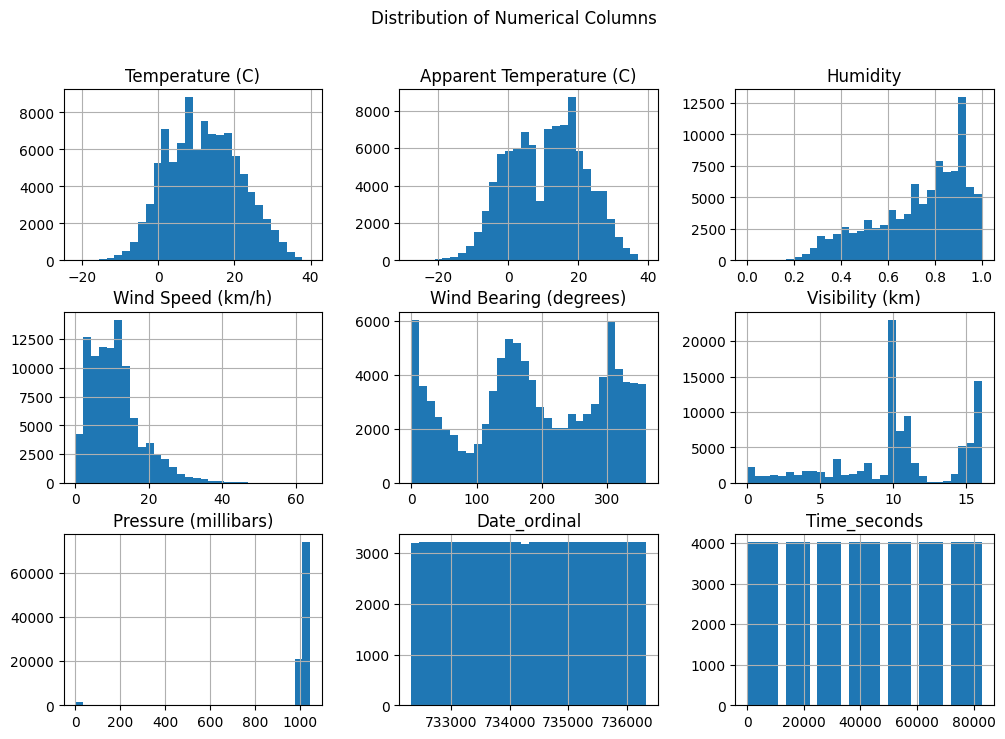

In [ ]:
df.hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Columns")
plt.show()


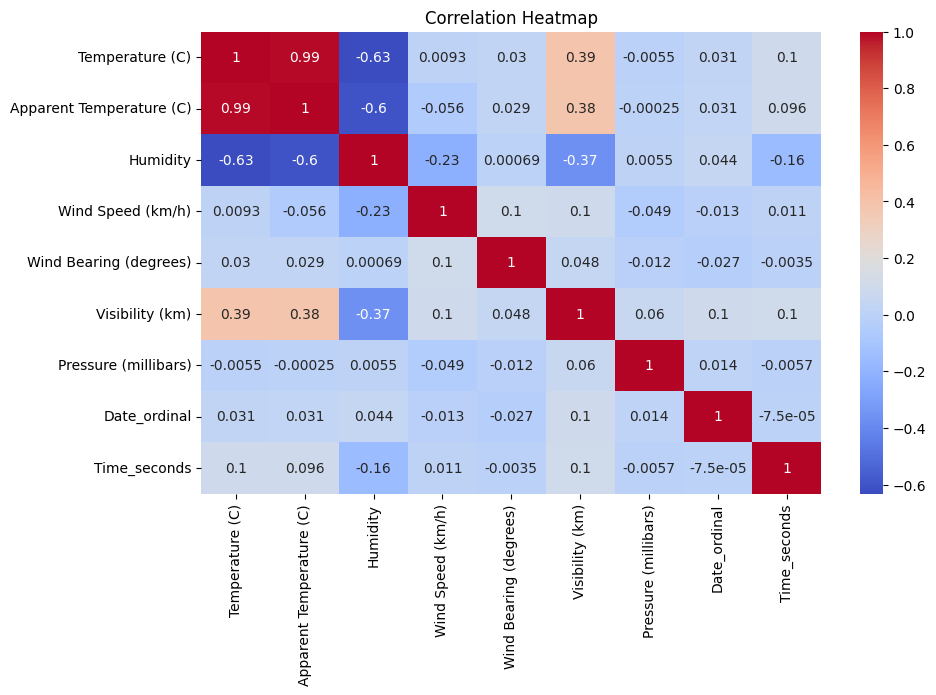

In [ ]:
#قياس العلاقة بين المتغيرات مع بعضها
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


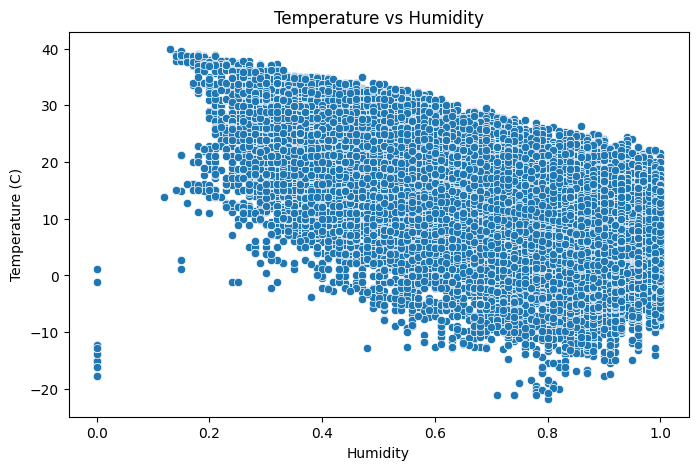

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Humidity", y="Temperature (C)", data=df)
plt.title("Temperature vs Humidity")
plt.show()


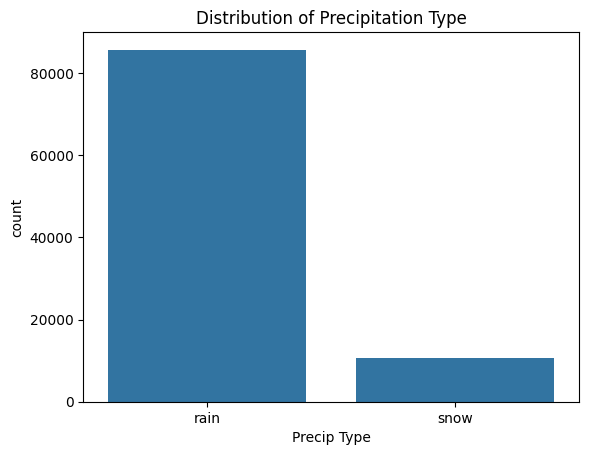

In [ ]:
sns.countplot(x="Precip Type", data=df)
plt.title("Distribution of Precipitation Type")
plt.show()


In [ ]:
df["Precip Type"].value_counts()

,count
Precip Type,
rain,85717
snow,10712


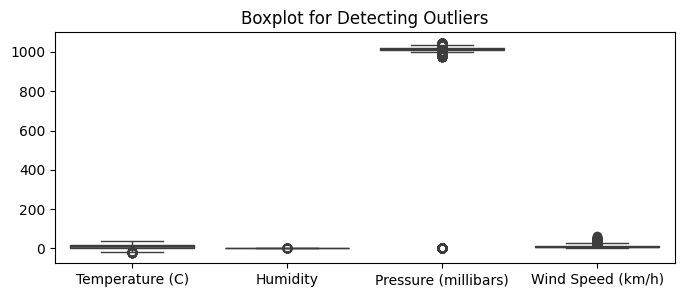

In [ ]:
plt.figure(figsize=(8,3))
sns.boxplot(data=df[["Temperature (C)", "Humidity", "Pressure (millibars)", "Wind Speed (km/h)"]])
plt.title("Boxplot for Detecting Outliers")
plt.show()

In [ ]:
from scipy import stats

z_scores = stats.zscore(df[["Temperature (C)", "Humidity", "Pressure (millibars)", "Wind Speed (km/h)"]])
abs_z_scores = abs(z_scores)

# نختار القيم اللي بعدها أكثر من 3 عن المتوسط
outliers = (abs_z_scores > 3).any(axis=1)
print("عدد الصفوف اللي فيها Outliers:", outliers.sum())


عدد الصفوف اللي فيها Outliers: 2518


In [ ]:
Q1 = df["Temperature (C)"].quantile(0.25)
Q3 = df["Temperature (C)"].quantile(0.75)
IQR = Q3 - Q1

# تحديد النطاق المسموح
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# استخراج القيم الشاذة
outliers = df[(df["Temperature (C)"] < lower) | (df["Temperature (C)"] > upper)]
print("عدد القيم الشاذة في الحرارة:", len(outliers))


عدد القيم الشاذة في الحرارة: 44


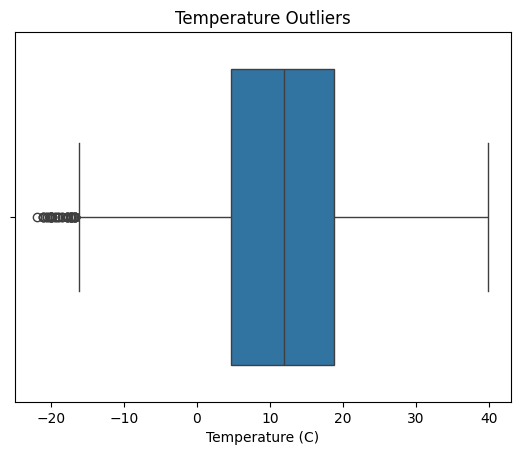

In [ ]:
sns.boxplot(x=df["Temperature (C)"])
plt.title("Temperature Outliers")
plt.show()


In [ ]:
for col in ["Temperature (C)", "Humidity", "Pressure (millibars)", "Wind Speed (km/h)"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


In [ ]:
from scipy import stats

z_scores = stats.zscore(df[["Temperature (C)", "Humidity", "Pressure (millibars)", "Wind Speed (km/h)"]])
abs_z_scores = abs(z_scores)

# نختار القيم اللي بعدها أكثر من 3 عن المتوسط
outliers = (abs_z_scores > 3).any(axis=1)
print("عدد الصفوف اللي فيها Outliers:", outliers.sum())


عدد الصفوف اللي فيها Outliers: 0


In [ ]:
df['Summary'].value_counts().head(10)


,count
Summary,
Partly Cloudy,31726
Mostly Cloudy,28094
Overcast,16597
Clear,10873
Foggy,7148
Breezy and Overcast,528
Breezy and Mostly Cloudy,516
Breezy and Partly Cloudy,386
Dry and Partly Cloudy,86


In [ ]:
df = df.reset_index(drop=True)
df.head()


,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary,Date,Time,Date_ordinal,Time_seconds
0,Partly Cloudy,rain,9.47,7.39,0.89,14.12,251.00,15.83,1015.13,Partly cloudy throughout the day.,2006-03-31,22:00:00,732401,79200
1,Partly Cloudy,rain,9.36,7.23,0.86,14.26,259.00,15.83,1015.63,Partly cloudy throughout the day.,2006-03-31,23:00:00,732401,82800
2,Mostly Cloudy,rain,9.38,9.38,0.89,3.93,204.00,14.96,1015.94,Partly cloudy throughout the day.,2006-04-01,00:00:00,732402,0
3,Partly Cloudy,rain,8.29,5.94,0.83,14.10,269.00,15.83,1016.41,Partly cloudy throughout the day.,2006-04-01,01:00:00,732402,3600
4,Mostly Cloudy,rain,8.76,6.98,0.83,11.04,259.00,15.83,1016.51,Partly cloudy throughout the day.,2006-04-01,02:00:00,732402,7200


forcast

preprosesing

<Axes: ylabel='Temperature (C)'>

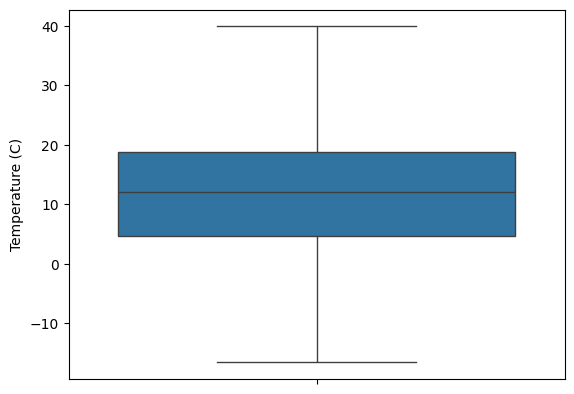

In [ ]:
sns.boxplot(df["Temperature (C)"])


In [ ]:
# 6️⃣ Feature Engineering
# ===============================
df["Temp_diff"] = df["Temperature (C)"] - df["Apparent Temperature (C)"]
df["Temp_diff"] = pd.to_numeric(df["Temp_diff"], errors='coerce')

قياس العلاقة ومشاهدة اذا يوجد عندي multicolineariality

In [ ]:
# 1. اختيار الأعمدة (X) والهدف (y)
X = df[["Summary", "Precip Type", "Humidity", "Wind Speed (km/h)",
    "Visibility (km)", "Pressure (millibars)",
    "Date_ordinal", "Time_seconds","Temp_diff"]]
y = df["Temperature (C)"]

# 2. حساب VIF قبل التدريب
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

X = X.select_dtypes(include=[float, int])
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)




                Feature       VIF
0                 const 425250.12
1              Humidity      1.40
2     Wind Speed (km/h)      1.56
3       Visibility (km)      1.22
4  Pressure (millibars)      1.13
5          Date_ordinal      1.02
6          Time_seconds      1.03
7             Temp_diff      1.50


قياس الlinearity

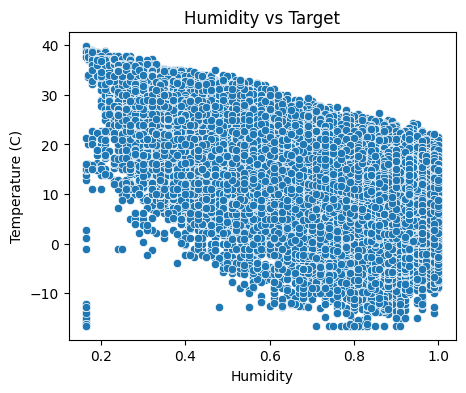

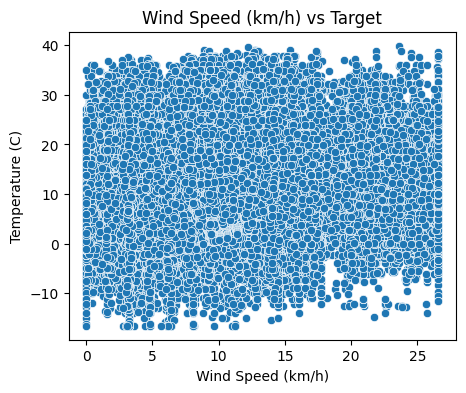

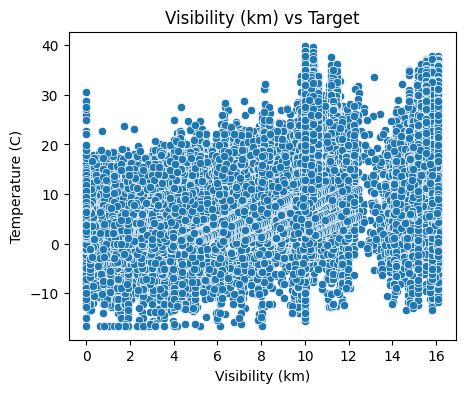

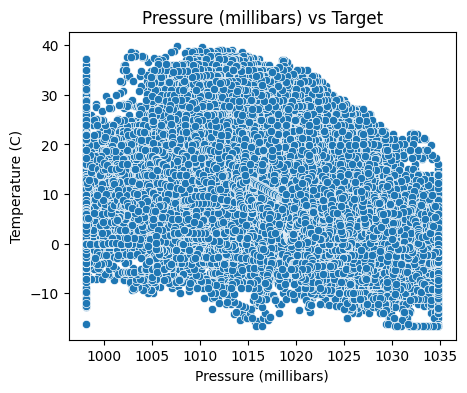

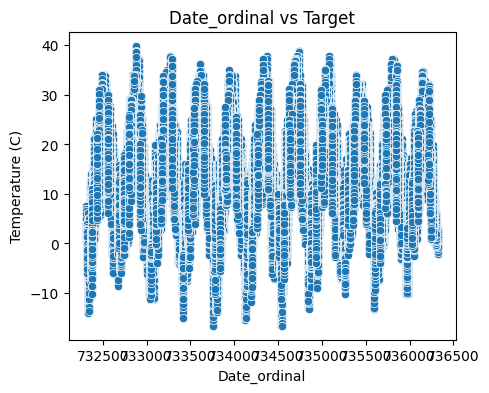

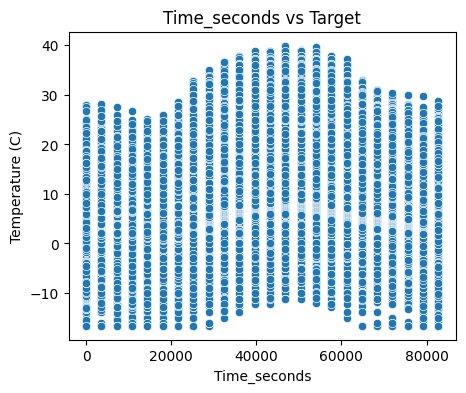

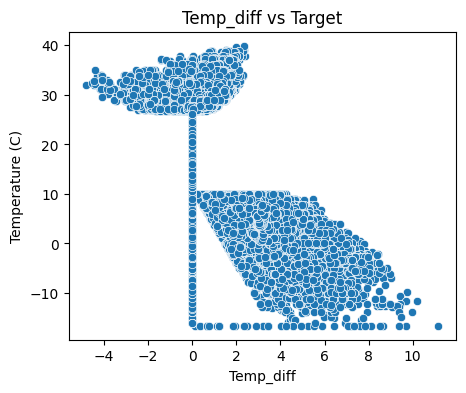

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# نفترض y = الهدف، X = DataFrame المتغيرات المستقلة
for col in X.columns:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=X[col], y=y)
    plt.title(f"{col} vs Target")
    plt.show()


In [ ]:
y = df["Temperature (C)"]

# بدون Apparent Temperature لتجنب تسرب البيانات
selected_features = [
    "Summary", "Precip Type", "Humidity", "Wind Speed (km/h)",
    "Visibility (km)", "Pressure (millibars)",
    "Date_ordinal", "Time_seconds","Temp_diff"
]
X = df[selected_features]


In [ ]:

# تحويل القيم النصية إلى أرقام (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# تحويل كل القيم True/False داخل X فقط إلى 1/0
X = X.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

# عرض أول 5 صفوف
print(X.head())



   Humidity  Wind Speed (km/h)  Visibility (km)  Pressure (millibars)  \
0      0.89              14.12            15.83               1015.13   
1      0.86              14.26            15.83               1015.63   
2      0.89               3.93            14.96               1015.94   
3      0.83              14.10            15.83               1016.41   
4      0.83              11.04            15.83               1016.51   

   Date_ordinal  Time_seconds  Temp_diff  Summary_Breezy and Dry  \
0        732401         79200       2.08                       0   
1        732401         82800       2.13                       0   
2        732402             0       0.00                       0   
3        732402          3600       2.34                       0   
4        732402          7200       1.78                       0   

   Summary_Breezy and Foggy  Summary_Breezy and Mostly Cloudy  ...  \
0                         0                                 0  ...   
1           

In [ ]:
# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:

# تحجيم البيانات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# 1. إنشاء النموذج
linear = LinearRegression()
# 2. تدريب النموذج
linear.fit(X_train_scaled, y_train)
# 3. التنبؤ
y_pred = linear.predict(X_test_scaled)
# 4. التقييم
r2_train = linear.score(X_train_scaled, y_train)
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# 5. عرض النتائج
print("===== MODEL EVALUATION =====")
print(f"Train R²: {r2_train:.3f}")
print(f"Test  R²: {r2_test:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

===== MODEL EVALUATION =====
Train R²: 0.757
Test  R²: 0.758
MAE: 3.767
RMSE: 4.703


In [ ]:
# 4. بناء النموذج الخطي المحسّن
# ==========================================
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Ridge = Linear Regression مع Regularization
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)


In [ ]:

# 5. التقييم
# ==========================================
r2_train = model.score(X_train_poly, y_train)
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== MODEL EVALUATION =====")
print(f"Train R²: {r2_train:.3f}")
print(f"Test  R²: {r2_test:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

===== MODEL EVALUATION =====
Train R²: 0.863
Test  R²: 0.858
MAE: 2.582
RMSE: 3.608


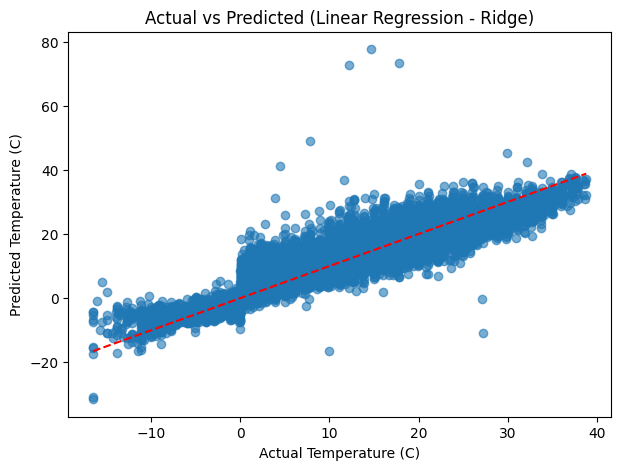

In [ ]:
# ==========================================
# 6. رسم القيم الحقيقية مقابل المتوقعة
# ==========================================
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Temperature (C)")
plt.ylabel("Predicted Temperature (C)")
plt.title("Actual vs Predicted (Linear Regression - Ridge)")
plt.show()

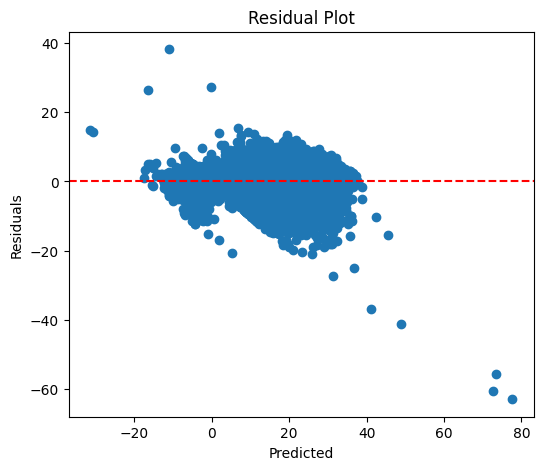

In [ ]:
#2) Residual Plot

#يكشف إذا فيه مشاكل مثل عدم الخطية أوheteroscedasticity.
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


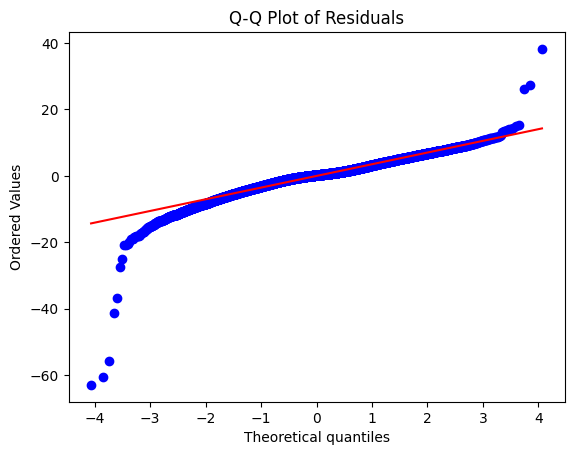

In [ ]:
#Normal Q-Q Plot للـ residuals
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


['weather_model.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
import joblib
from sklearn.preprocessing import PolynomialFeatures

# بعد إنشاء X (بعد One-Hot و تحويل bool -> int)
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')   # حفظ أسماء الأعمدة

# احفظ الـ PolynomialFeatures المُستخدم لاحقاً (degree=3 كما استخدمتي)
poly = PolynomialFeatures(degree=3, include_bias=False)
# لاحقاً استعملتي poly.fit_transform على X_train_scaled، لكن هنا نحفظ الـ object نفسه
joblib.dump(poly, 'poly_transformer.pkl')

# ثم استمري في تقسيم/تدريب كما عندك
# وفي نهاية التدريب احفظ الموديل و الـ scaler كما فعلتي:
joblib.dump(model, 'weather_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
print(X.columns.tolist())


['Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'Date_ordinal', 'Time_seconds', 'Temp_diff', 'Summary_Breezy and Dry', 'Summary_Breezy and Foggy', 'Summary_Breezy and Mostly Cloudy', 'Summary_Breezy and Overcast', 'Summary_Breezy and Partly Cloudy', 'Summary_Clear', 'Summary_Dangerously Windy and Partly Cloudy', 'Summary_Drizzle', 'Summary_Dry', 'Summary_Dry and Mostly Cloudy', 'Summary_Dry and Partly Cloudy', 'Summary_Foggy', 'Summary_Humid and Mostly Cloudy', 'Summary_Humid and Overcast', 'Summary_Humid and Partly Cloudy', 'Summary_Light Rain', 'Summary_Mostly Cloudy', 'Summary_Overcast', 'Summary_Partly Cloudy', 'Summary_Rain', 'Summary_Windy', 'Summary_Windy and Dry', 'Summary_Windy and Foggy', 'Summary_Windy and Mostly Cloudy', 'Summary_Windy and Overcast', 'Summary_Windy and Partly Cloudy', 'Precip Type_snow']
